# Assignment - Unsupervise Learning
In this assignment, we apply clustering and dimension reduction on Breast Cancer dataset from scikit-learn.
We will explore:

1. **Clustering**: find potential group in the data.
2. **PCA**: reduce feature dimensions while keeping important information
3. **Model comparison**: check performance before and after PCA

## 1. Introduction & Setup
1. Load Breast Cancer dataset from scikit-learn.
2. Understand and explore the data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer

# Load data as a DataFrame
data = load_breast_cancer(as_frame=True)
df = data.frame.copy()

print('Dataset shape:', df.shape)
display(df.head())

Dataset shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## Unsupervised Learning Task: Clustering

#### Separate features (X) and target (Y), find potential groups on input features (X) using k-means.

Clustering algorithms are scale-sensitive, so normalize data first.

In [2]:
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['target'])
y = df['target']

scaler = StandardScaler()
X_norm = scaler.fit_transform(X)

#### TODO: 
1. Build k-means model.
2. Evaluate through SSE or Silhouette and visualize it.
3. Find `K` for k-means

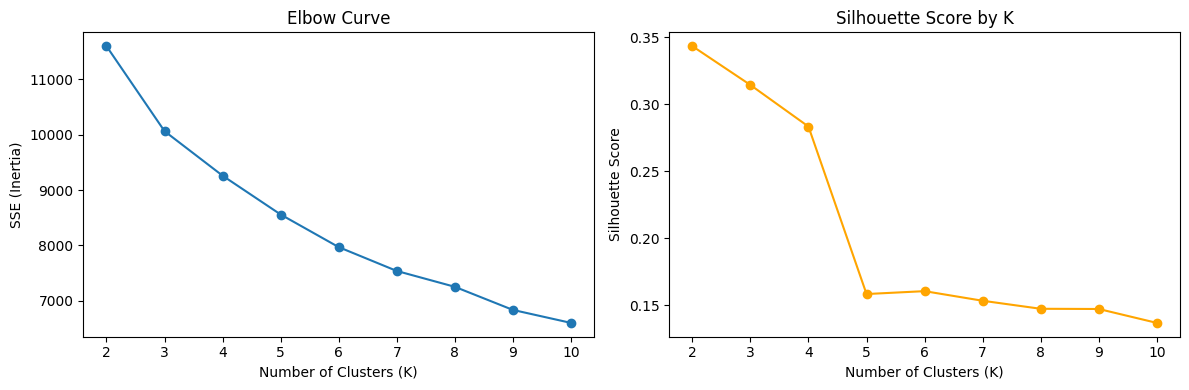

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score

sse = []
silhouette_scores = []
K_range = range(2,11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_norm)
    sse.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_norm, km.labels_))
    



fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Elbow plot SSE
axes[0].plot(K_range, sse, marker='o')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('SSE (Inertia)')
axes[0].set_title('Elbow Curve')

# Silhouette plot
axes[1].plot(K_range, silhouette_scores, marker='o', color='orange')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by K')

plt.tight_layout()
plt.show()

# Best K = 3 



## Supervised Learning Task: Classification with/without dimension reduction

#### Step1: Split into train/test and normalize.

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Train shape:', X_train_scaled.shape)
print('Test shape :', X_test_scaled.shape)
print('Shown shape: (ROWS, COLS)')

Train shape: (455, 30)
Test shape : (114, 30)
Shown shape: (ROWS, COLS)


#### Step 2: Apply PCA on input data

TODO:
1. Fit PCA on normalized training data.
2. Visualize the importance of principal components though scree plot.
3. Transform train/test data to reduced dimensions.

In [5]:
from sklearn.decomposition import PCA

# TODO: fit PCA() on X_train_scaled
# pca_full = ...
# pca_full.fit(...)

# TODO: compute cumulative explained variance
# cum_var = ...
# n_components_95 = ...

# TODO: print number of components

# TODO: plot cumulative explained variance curve with 95% horizontal line

# TODO: fit PCA with selected components and transform train/test
# pca = ...
# X_train_pca = ...
# X_test_pca = ...

# TODO: print original and PCA train shapes

#### Step 3: Classification before and after PCA
Train a classifier (e.g. Logistic Regression, Random Forest, etc) on:
1. Original scaled features
2. PCA-reduced features
Then compare test accuracy.

In [6]:
# TODO: import Classifier, accuracy_score, classification_report

# TODO: train model on X_train_scaled and predict X_test_scaled
# model_original = ...
# y_pred_original = ...
# acc_original = ...

# TODO: train model on X_train_pca and predict X_test_pca
# model_pca = ...
# y_pred_pca = ...
# acc_pca = ...

# TODO: print both accuracies

# TODO: print classification_report for PCA model

## Questions
Answer briefly:
1. Which `K` did you choose for K-Means, and why?
2. How many principal components were needed for 95% variance?
3. Did PCA improve or reduce the test accuracy? Why might that happen?
4. Why did we normalize data before K-means and PCA?

In [7]:
# Write your short answers here as Python comments
# Q1:
# Q2:
# Q3:
# Q4: